# Importing Libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data

In [2]:

df_flipkart = pd.read_csv(r"..\data\Kaggle_dataset\flipkart_product.csv", encoding='latin-1')
df_amazon = pd.read_csv(r"..\data\Kaggle_dataset\amazon_review.csv", encoding='latin-1')


print("Flipkart dataset shape:", df_flipkart.shape)
print("Amazon dataset shape:", df_amazon.shape)
print("Flipkart sample data:")
print(df_flipkart.head())
print("Amazon sample data:")
print(df_amazon.head())


Flipkart dataset shape: (189874, 5)
Amazon dataset shape: (4915, 12)
Flipkart sample data:
                                         ProductName     Price Rate  \
0  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  ??3,999    5   
1  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  ??3,999    5   
2  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  ??3,999    3   
3  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  ??3,999    1   
4  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  ??3,999    3   

            Review                                            Summary  
0           Super!  Great cooler.. excellent air flow and for this...  
1          Awesome             Best budget 2 fit cooler. Nice cooling  
2             Fair  The quality is good but the power of air is de...  
3  Useless product                 Very bad product it's a only a fan  
4             Fair                                      Ok ok product  
Amazon sample data:
       reviewerID        asin 

# View Data

In [3]:
# Flipkart dataset
print("Flipkart Dataset:")
print(df_flipkart.head())      # first 5 rows
print(df_flipkart.tail())      # last 5 rows
print(df_flipkart.sample(5))   # random 5 rows
print(df_flipkart.info())      # column types and non-null counts
print(df_flipkart.describe())  # summary statistics for numeric columns

# Amazon dataset
print("\nAmazon Dataset:")
print(df_amazon.head())
print(df_amazon.tail())
print(df_amazon.sample(5))
print(df_amazon.info())
print(df_amazon.describe())



Flipkart Dataset:
                                         ProductName     Price Rate  \
0  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  ??3,999    5   
1  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  ??3,999    5   
2  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  ??3,999    3   
3  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  ??3,999    1   
4  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  ??3,999    3   

            Review                                            Summary  
0           Super!  Great cooler.. excellent air flow and for this...  
1          Awesome             Best budget 2 fit cooler. Nice cooling  
2             Fair  The quality is good but the power of air is de...  
3  Useless product                 Very bad product it's a only a fan  
4             Fair                                      Ok ok product  
                                              ProductName   Price Rate  \
189869  NIVEA Soft Light Moisturizer for Face, Ha

#  Merging DataFrames

In [4]:
df_merged = pd.merge(df_flipkart, df_amazon, left_on='ProductName', right_on='asin', how='outer')

print("Merged dataset shape:", df_merged.shape)
print(df_merged.head())


Merged dataset shape: (194789, 17)
                                         ProductName   Price Rate_x Review_x  \
0                                                       NaN    NaN      NaN   
1  1170-BL-BR Unique New Day & Date Analog Watch ...  â¹299      5      Nan   
2  1170-BL-BR Unique New Day & Date Analog Watch ...  â¹299      4      Nan   
3  1170-BL-BR Unique New Day & Date Analog Watch ...  â¹299      5      Nan   
4  1170-BL-BR Unique New Day & Date Analog Watch ...  â¹299      5      Nan   

                                           Summary_x reviewerID asin  \
0                                                NaN        NaN  NaN   
1  Very nice and must buy product....First of all...        NaN  NaN   
2  Superb watch, quality is also good and belt is...        NaN  NaN   
3  An Awesome looking Watch from Fogg fashion ,It...        NaN  NaN   
4  The Watch Have Impressive Look. The Dial Pad O...        NaN  NaN   

  reviewerName helpful Review_y  Rate_y Summary_y  

# Concatenate both datasets vertically

In [5]:
df_flipkart['ProductDetails'] = df_flipkart['ProductName']  # Flipkart uses ProductName
df_amazon['ProductDetails'] = df_amazon['asin']            # Amazon uses asin

df_flipkart['Source'] = 'Flipkart'
df_amazon['Source'] = 'Amazon'

# Now combine datasets vertically
common_cols = ['Review', 'Rate', 'Source', 'ProductDetails']
df_combined = pd.concat([df_flipkart[common_cols], df_amazon[common_cols]], axis=0, ignore_index=True)

print("Combined dataset shape:", df_combined.shape)
print(df_combined.head())
# Check last 5 rows
print(df_combined.tail())

# Or check distribution of Source column
print(df_combined['Source'].value_counts())



Combined dataset shape: (194789, 4)
            Review Rate    Source  \
0           Super!    5  Flipkart   
1          Awesome    5  Flipkart   
2             Fair    3  Flipkart   
3  Useless product    1  Flipkart   
4             Fair    3  Flipkart   

                                      ProductDetails  
0  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  
1  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  
2  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  
3  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  
4  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  
                                                   Review Rate  Source  \
194784  I bought this Sandisk 16GB Class 10 to use wit...    1  Amazon   
194785  Used this for extending the capabilities of my...    5  Amazon   
194786  Great card that is very fast and reliable. It ...    5  Amazon   
194787  Good amount of space for the stuff I want to d...    5  Amazon   
194788  I've heard bad things about this 

# Inspect Structure

In [6]:
df_combined.shape              # Rows and columns
df_combined.columns            # Column names
df_combined.info()             # Data types and nulls
df_combined.describe()         # Summary stats

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194789 entries, 0 to 194788
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Review          194784 non-null  object
 1   Rate            194788 non-null  object
 2   Source          194789 non-null  object
 3   ProductDetails  194789 non-null  object
dtypes: object(4)
memory usage: 5.9+ MB


,Review,Rate,Source,ProductDetails
count,194784,194788,194789,194789
unique,6173,14,2,813
top,Nan,5,Flipkart,MILTON Thermosteel Flip Lid 500 ml FlaskÂ Â (P...
freq,20862,108694,189874,9278


#  Handle Missing Data

In [7]:

# Drop rows with missing Review or Rate
df_combined = df_combined.dropna(subset=['Review', 'Rate'])

# Convert 'Rate' to numeric
df_combined['Rate'] = pd.to_numeric(df_combined['Rate'], errors='coerce')

# fill any newly created NaNs in Rate  with median
df_combined['Rate'] = df_combined['Rate'].fillna(df_combined['Rate'].median())

print("After handling missing data:")
print(df_combined.info())


After handling missing data:
<class 'pandas.core.frame.DataFrame'>
Index: 194784 entries, 0 to 194788
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Review          194784 non-null  object 
 1   Rate            194784 non-null  float64
 2   Source          194784 non-null  object 
 3   ProductDetails  194784 non-null  object 
dtypes: float64(1), object(3)
memory usage: 7.4+ MB
None


#  Remove Duplicates

In [8]:

df_combined = df_combined.drop_duplicates(subset=['ProductDetails','Rate','Review','Source'])
print("After removing duplicates:")
print(df_combined.shape)
print(df_combined.head())
print(df_combined.tail())

After removing duplicates:
(32733, 4)
               Review  Rate    Source  \
0              Super!   5.0  Flipkart   
1             Awesome   5.0  Flipkart   
2                Fair   3.0  Flipkart   
3     Useless product   1.0  Flipkart   
6  Highly recommended   5.0  Flipkart   

                                      ProductDetails  
0  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  
1  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  
2  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  
3  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  
6  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  
                                                   Review  Rate  Source  \
194784  I bought this Sandisk 16GB Class 10 to use wit...   1.0  Amazon   
194785  Used this for extending the capabilities of my...   5.0  Amazon   
194786  Great card that is very fast and reliable. It ...   5.0  Amazon   
194787  Good amount of space for the stuff I want to d...   5.0  Amazon   
194788  I'

#  Selecting Columns

In [9]:

df_final = df_combined[['ProductDetails','Rate','Review','Source']]


print("Final dataset columns:", df_final.columns)
print(df_final.head())
print(df_final.tail())
print("Final dataset shape:", df_final.shape)


Final dataset columns: Index(['ProductDetails', 'Rate', 'Review', 'Source'], dtype='object')
                                      ProductDetails  Rate  \
0  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...   5.0   
1  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...   5.0   
2  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...   3.0   
3  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...   1.0   
6  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...   5.0   

               Review    Source  
0              Super!  Flipkart  
1             Awesome  Flipkart  
2                Fair  Flipkart  
3     Useless product  Flipkart  
6  Highly recommended  Flipkart  
       ProductDetails  Rate  \
194784     B007WTAJTO   1.0   
194785     B007WTAJTO   5.0   
194786     B007WTAJTO   5.0   
194787     B007WTAJTO   5.0   
194788     B007WTAJTO   5.0   

                                                   Review  Source  
194784  I bought this Sandisk 16GB Class 10 to use wit...  Amazon  
194785 

#  Filtering Rows

In [10]:

df_filtered = df_final[df_final['Rate'] >= 1]

print("Filtered dataset shape:", df_filtered.shape)
print(df_filtered.head())
print(df_filtered.tail())



Filtered dataset shape: (32733, 4)
                                      ProductDetails  Rate  \
0  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...   5.0   
1  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...   5.0   
2  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...   3.0   
3  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...   1.0   
6  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...   5.0   

               Review    Source  
0              Super!  Flipkart  
1             Awesome  Flipkart  
2                Fair  Flipkart  
3     Useless product  Flipkart  
6  Highly recommended  Flipkart  
       ProductDetails  Rate  \
194784     B007WTAJTO   1.0   
194785     B007WTAJTO   5.0   
194786     B007WTAJTO   5.0   
194787     B007WTAJTO   5.0   
194788     B007WTAJTO   5.0   

                                                   Review  Source  
194784  I bought this Sandisk 16GB Class 10 to use wit...  Amazon  
194785  Used this for extending the capabilities of my...  Amazon

#  Sorting Data

In [16]:
#  Sort by 'Rate' in descending order (highest rated reviews first)
df_sorted_rate = df_filtered.sort_values(by='Rate', ascending=False)

#  Sort by 'Source' and then by 'Rate' descending
df_sorted_source_rate = df_filtered.sort_values(by=['Source', 'Rate'], ascending=[True, False])


print(df_sorted_rate.head())

print(df_sorted_source_rate.head())


                                           ProductDetails  Rate  \
194788                                         B007WTAJTO   5.0   
0       Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...   5.0   
1       Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...   5.0   
194787                                         B007WTAJTO   5.0   
194786                                         B007WTAJTO   5.0   

                                                   Review    Source  
194788  Ive heard bad things about this 64gb Micro SD ...    Amazon  
0                                                   Super  Flipkart  
1                                                 Awesome  Flipkart  
194787  Good amount of space for the stuff I want to d...    Amazon  
194786  Great card that is very fast and reliable It c...    Amazon  
       ProductDetails  Rate  \
189875     B007WTAJTO   5.0   
189877     B007WTAJTO   5.0   
189878     B007WTAJTO   5.0   
189879     B007WTAJTO   5.0   
189880     B007WTAJTO 

#  Grouping and Aggregation

In [12]:
#  Average rating by Source
avg_rate_source = df_filtered.groupby('Source')['Rate'].mean()
print("Average rating by Source:")
print(avg_rate_source)

#  Count of reviews by Source
count_reviews_source = df_filtered.groupby('Source')['Review'].count()
print("\nNumber of reviews by Source:")
print(count_reviews_source)

#  Max and Min rating by Source
min_max_rate_source = df_filtered.groupby('Source')['Rate'].agg(['min', 'max'])
print("\nMin and Max rating by Source:")
print(min_max_rate_source)


Average rating by Source:
Source
Amazon      4.587505
Flipkart    3.550954
Name: Rate, dtype: float64

Number of reviews by Source:
Source
Amazon       4914
Flipkart    27819
Name: Review, dtype: int64

Min and Max rating by Source:
          min  max
Source            
Amazon    1.0  5.0
Flipkart  1.0  5.0


#  Aggregating Multiple Columns

In [13]:

#  Aggregate Rate with multiple functions per Source
agg_stats = df_filtered.groupby('Source').agg({
    'Rate': ['mean', 'min', 'max', 'count'],  # multiple aggregations on Rate
    'Review': 'count'                         # count of reviews
})

print("Aggregated statistics by Source:")
print(agg_stats)


Aggregated statistics by Source:
              Rate                  Review
              mean  min  max  count  count
Source                                    
Amazon    4.587505  1.0  5.0   4914   4914
Flipkart  3.550954  1.0  5.0  27819  27819


#  Cleaning text - remove emojis, special characters, symbols

In [14]:

import re

def clean_text(text):
    # Remove non-alphanumeric characters (keep letters, numbers, spaces)
    text = re.sub(r'[^A-Za-z0-9\s]+', '', str(text))
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning to the Review column
df_filtered['Review'] = df_filtered['Review'].apply(clean_text)


print("Sample cleaned reviews:")
print(df_filtered['Review'].head())


Sample cleaned reviews:
0                 Super
1               Awesome
2                  Fair
3       Useless product
6    Highly recommended
Name: Review, dtype: object


#  Save Cleaned Dataset

In [15]:
# Save cleaned DataFrame to CSV
df_filtered.to_csv(r"..\data\cleaned_product_reviews.csv", index=False)

# Save cleaned DataFrame to Excel

df_filtered.to_excel(r"..\data\cleaned_product_reviews_v2.xlsx", index=False)


print("Files saved successfully")


Files saved successfully


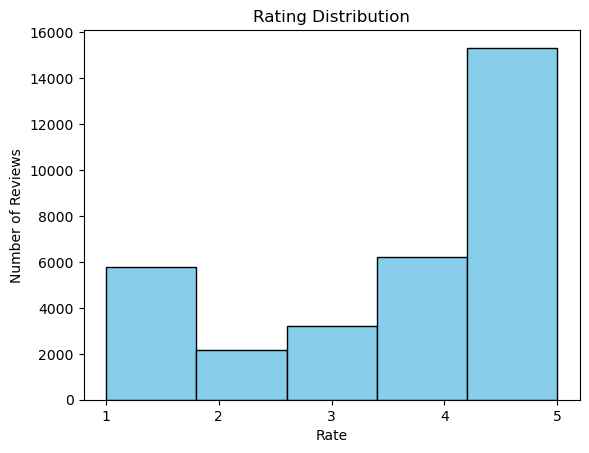

In [25]:
plt.hist(df_filtered['Rate'], bins=5, color='skyblue', edgecolor='black')
plt.title("Rating Distribution")
plt.xlabel("Rate")
plt.ylabel("Number of Reviews")
plt.xticks(range(1, 6))
plt.show()


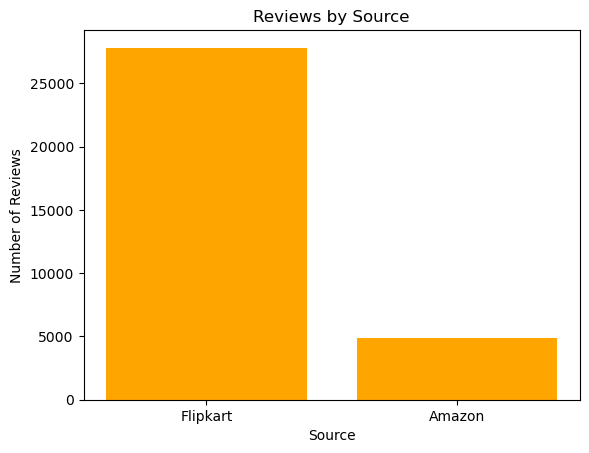

In [19]:
source_counts = df_filtered['Source'].value_counts()
plt.bar(source_counts.index, source_counts.values, color='orange')
plt.title("Reviews by Source")
plt.xlabel("Source")
plt.ylabel("Number of Reviews")
plt.show()


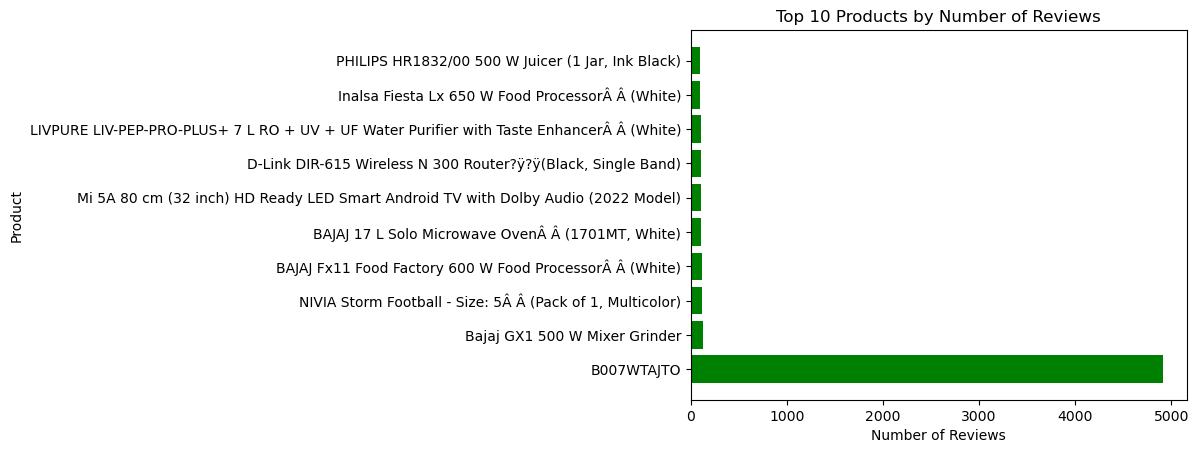

In [20]:
top_products = df_filtered['ProductDetails'].value_counts().head(10)
plt.barh(top_products.index, top_products.values, color='green')
plt.title("Top 10 Products by Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Product")
plt.show()
